## GPU Check + Setup

In [1]:
import torch
print(f"CUDA available : {torch.cuda.is_available()}")
print(f"GPU            : {torch.cuda.get_device_name(0) if torch.cuda.is_available() else '❌ No GPU — go to Runtime > Change runtime type > T4'}")

from google.colab import drive
drive.mount('/content/drive')
!pip install -q ultralytics scikit-learn

CUDA available : True
GPU            : Tesla T4
Mounted at /content/drive
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 32.2 MB/s eta 0:00:00


## Download Custom Dataset

In [2]:
import gdown, os, zipfile

os.makedirs("/content/custom_dataset", exist_ok=True)

# ── DOWNLOAD ZIP ──────────────────────────────────────────────
print("⏳ Downloading custom dataset zip...")
gdown.download(
    "https://drive.google.com/uc?id=1Vyi1GgABlR6V_QvNkNuovnlLnWZID8hA",
    "/content/custom_dataset.zip",
    quiet=False
)

size = os.path.getsize("/content/custom_dataset.zip")
print(f"✅ Downloaded: {size/1e6:.1f} MB")

# ── UNZIP ─────────────────────────────────────────────────────
print("⏳ Extracting...")
with zipfile.ZipFile("/content/custom_dataset.zip", 'r') as z:
    z.extractall("/content/custom_dataset")
print("✅ Extracted!")

# ── SHOW FULL STRUCTURE ───────────────────────────────────────
print("\n📁 Contents:")
for root, dirs, files in os.walk("/content/custom_dataset"):
    level = root.replace("/content/custom_dataset", "").count(os.sep)
    indent = "  " * level
    print(f"{indent}📁 {os.path.basename(root)}/")
    sub = "  " * (level + 1)
    imgs = [f for f in files if f.lower().endswith(('.jpg','.jpeg','.png'))]
    csvs = [f for f in files if f.endswith('.csv')]
    if imgs:
        print(f"{sub}🖼️  {len(imgs)} images")
        for f in imgs[:3]:
            print(f"{sub}   {f}")
        if len(imgs) > 3:
            print(f"{sub}   ... ({len(imgs)-3} more)")
    for c in csvs:
        print(f"{sub}📄 {c}")

# ── VERIFY ────────────────────────────────────────────────────
all_imgs = []
for root, dirs, files in os.walk("/content/custom_dataset"):
    all_imgs += [os.path.join(root,f) for f in files
                 if f.lower().endswith(('.jpg','.jpeg','.png'))]
all_csvs = []
for root, dirs, files in os.walk("/content/custom_dataset"):
    all_csvs += [os.path.join(root,f) for f in files if f.endswith('.csv')]

print(f"\n✅ Total images : {len(all_imgs)}")
print(f"✅ CSV files    : {all_csvs}")

⏳ Downloading custom dataset zip...


Downloading...
From (original): https://drive.google.com/uc?id=1Vyi1GgABlR6V_QvNkNuovnlLnWZID8hA
From (redirected): https://drive.google.com/uc?id=1Vyi1GgABlR6V_QvNkNuovnlLnWZID8hA&confirm=t&uuid=160e7a21-5e8f-4265-8918-a7521bcc4d50
To: /content/custom_dataset.zip
100%|██████████| 61.3M/61.3M [00:00<00:00, 70.9MB/s]


✅ Downloaded: 61.3 MB
⏳ Extracting...
✅ Extracted!

📁 Contents:
📁 custom_dataset/
  📁 New folder/
    🖼️  76 images
       Bhatura_100.jpg
       Koozh.jpeg
       sambhar_1.jpeg
       ... (73 more)
    📄 Label.csv

✅ Total images : 76
✅ CSV files    : ['/content/custom_dataset/New folder/Label.csv']


## Load & Clean CSV

In [4]:
import pandas as pd
import numpy as np
import os, glob

df = pd.read_csv("/content/custom_dataset/New folder/Label.csv")
df.columns = df.columns.str.strip().str.lower().str.replace('﻿','')
df = df.rename(columns={"image_name":"image_name", "weight":"weight", "class":"food_class"})
df['image_name'] = df['image_name'].astype(str).str.strip()
df['food_class'] = df['food_class'].astype(str).str.strip()

print(f"✅ CSV loaded: {len(df)} rows")
print(df.head(10).to_string())

# ── MATCH IMAGE NAMES TO ACTUAL FILES ────────────────────────
image_dir  = "/content/custom_dataset"
all_images = glob.glob(f"{image_dir}/**/*", recursive=True)
all_images = [f for f in all_images if f.lower().endswith(('.jpg','.jpeg','.png'))]

# Build lookup: stem → full path
img_lookup = {}
for path in all_images:
    stem = os.path.splitext(os.path.basename(path))[0].strip().lower()
    img_lookup[stem] = path

def find_image(name):
    # Try exact stem match first
    stem = os.path.splitext(str(name).strip())[0].lower()
    if stem in img_lookup:
        return img_lookup[stem]
    # Try partial match
    for key, path in img_lookup.items():
        if stem in key or key in stem:
            return path
    return None

df['image_path'] = df['image_name'].apply(find_image)

matched   = df['image_path'].notna().sum()
unmatched = df['image_path'].isna().sum()
print(f"\n✅ Matched  : {matched} rows")
print(f"⚠️  Unmatched: {unmatched} rows")

if unmatched > 0:
    print("\nUnmatched image names:")
    print(df[df['image_path'].isna()]['image_name'].tolist())

# Drop unmatched
df = df.dropna(subset=['image_path']).reset_index(drop=True)
print(f"\n✅ Final dataset: {len(df)} rows, {df['image_path'].nunique()} unique images")

✅ CSV loaded: 88 rows
   sr.no.           image_name  weight       food_class
0       1  IMG_20200414_181451     115           jalebi
1       2  IMG_20200504_185825     340      veg_biryani
2       3              biryani     130   mutton_biryani
3       4      coconut chutney      60  coconut_chutney
4       5                 idli      36             idli
5       6      pidi kozhkattai      32  pidi_kolukattai
6       7      pidi kozhkattai      82  pidi_kolukattai
7       8         onion pakoda      15     onion_pakoda
8       9         onion pakoda     250     onion_pakoda
9      10                 dosa      96             dosa

✅ Matched  : 72 rows
⚠️  Unmatched: 16 rows

Unmatched image names:
['coconut chutney', 'pidi kozhkattai', 'pidi kozhkattai', 'onion pakoda', 'onion pakoda', 'sambar', 'sambar satham', 'coconut chutney', 'uzuntha vadai', 'paal kolukattai', 'parupu vadai', 'ven pongal', 'kaara chutney', 'white rice', 'IMG_20200816_085332', 'IMG_20200816_085333']

✅ Final datas

## Train/Test Split (by unique image)

In [5]:
from sklearn.model_selection import train_test_split

# Split by unique image (so same image doesn't appear in both sets)
unique_images = df['image_path'].unique()
train_imgs, test_imgs = train_test_split(unique_images, test_size=0.2, random_state=42)

df_train = df[df['image_path'].isin(train_imgs)].reset_index(drop=True)
df_test  = df[df['image_path'].isin(test_imgs)].reset_index(drop=True)

print(f"✅ Train: {len(df_train)} rows | {len(train_imgs)} unique images")
print(f"✅ Test : {len(df_test)}  rows | {len(test_imgs)}  unique images")
print(f"\nTrain classes: {df_train['food_class'].nunique()} unique")
print(f"Test  classes: {df_test['food_class'].nunique()}  unique")

✅ Train: 58 rows | 48 unique images
✅ Test : 14  rows | 13  unique images

Train classes: 46 unique
Test  classes: 14  unique


In [6]:
from ultralytics import YOLO

# ── DOWNLOAD DEMO MODEL FROM PUBLIC DRIVE ────────────────────
import gdown, os

os.makedirs("/content/models", exist_ok=True)

gdown.download_folder(
    url="https://drive.google.com/drive/folders/1bK3Ia12fVSq4G8yITiwxDZRhuRFmhqhm",
    output="/content/models",
    quiet=False,
    use_cookies=False
)

# Auto-find demo model (v3)
import glob
pt_files  = glob.glob("/content/models/**/*.pt", recursive=True)
demo_path = next((f for f in pt_files if 'v3' in f or 'demo' in f), pt_files[0] if pt_files else None)

print(f"📌 Demo model: {demo_path}")
yolo_model = YOLO(demo_path)
print("✅ YOLO demo model loaded!")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


Retrieving folder contents


Retrieving folder 1ljrrE7auR20p-tBtvhe6dCrqhNW3PhGV nutrivision_v1
Retrieving folder 1JiPw158v3ySH715xRH8t1M8A84Hm3gJD weights
Processing file 1ptxYRb3OGiCcD7k5uiaOXEReyKpYOHGA best.pt
Processing file 1ueRoOvzAJuSWuGVonzpBT-9RET5YCMd2 last.pt
Processing file 1p5gHVDo8WRNA5wawA4dn0_Pw9f3hQevg args.yaml
Processing file 1NaoJKHWCH-YUOT2gE5Cly05NilV1BYTK labels.jpg
Processing file 1dN0NcChqUjqFVcvjO9BzxWoprO6EbCcf results.csv
Processing file 1r_taZ0fkLxReKOyAmufnCiLpy_QmdzzS train_batch0.jpg
Processing file 1sqqoeqryJCI_H2mWheWRvKMSPDgTVUbU train_batch1.jpg
Processing file 18SXgkOt9syyZr6RgxeRODryyKdZOLL2o train_batch2.jpg
Retrieving folder 199010GA3xdpn5DwPrTnAQ1fXhEdFH2D4 nutrivision_v2_fast
Retrieving folder 1vAj6AgwttkzFnpp-I5Cc-Z5GomHA0FGn weights
Processing file 1U1Zmy7dj5xdEBg9oRO1-cyQllyPI6w7- args.yaml
Processing file 1FaTm1fFvdyGpgyEjTbmlnLC8VKrDHm8u labels.jpg
Processing file 1NRkUtnCAE82ymSs2mYpYPwdSUvSuo-5L train_batch0.jpg
Processing file 1P0F5tL89Y0CSq2wMp_2cCJcDTK75PUFj tra

Retrieving folder contents completed
Building directory structure
Building directory structure completed
Downloading...
From (original): https://drive.google.com/uc?id=1ptxYRb3OGiCcD7k5uiaOXEReyKpYOHGA
From (redirected): https://drive.google.com/uc?id=1ptxYRb3OGiCcD7k5uiaOXEReyKpYOHGA&confirm=t&uuid=b94ca504-b413-4e1c-9883-999723955cb4
To: /content/models/nutrivision_v1/weights/best.pt
100%|██████████| 55.8M/55.8M [00:00<00:00, 113MB/s]
Downloading...
From (original): https://drive.google.com/uc?id=1ueRoOvzAJuSWuGVonzpBT-9RET5YCMd2
From (redirected): https://drive.google.com/uc?id=1ueRoOvzAJuSWuGVonzpBT-9RET5YCMd2&confirm=t&uuid=70035c48-27c7-41b1-8fd3-548f341624d5
To: /content/models/nutrivision_v1/weights/last.pt
100%|██████████| 55.8M/55.8M [00:00<00:00, 187MB/s]
Downloading...
From: https://drive.google.com/uc?id=1p5gHVDo8WRNA5wawA4dn0_Pw9f3hQevg
To: /content/models/nutrivision_v1/args.yaml
100%|██████████| 1.68k/1.68k [00:00<00:00, 2.04MB/s]
Downloading...
From: https://drive.goog

📌 Demo model: /content/models/nutrivision_v3_demo/weights/last.pt
✅ YOLO demo model loaded!



Download completed


## Run YOLO on All Custom Images → Extract Pixel Features
YOLO + SAM-2 Segmentation

In [8]:
# ── INSTALL SAM-2 ─────────────────────────────────────────────
!pip install -q sam2

import torch
import numpy as np
import cv2
import pandas as pd
from tqdm import tqdm
from sam2.build_sam import build_sam2
from sam2.sam2_image_predictor import SAM2ImagePredictor

# ── LOAD SAM-2 MODEL (auto downloads ~180MB) ──────────────────
print("⏳ Loading SAM-2...")
predictor = SAM2ImagePredictor.from_pretrained("facebook/sam2-hiera-small")
print("✅ SAM-2 loaded!")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 152.8/152.8 kB 7.1 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.2/42.2 kB 4.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.5/154.5 kB 11.3 MB/s eta 0:00:00
⏳ Loading SAM-2...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


sam2_hiera_small.pt:   0%|          | 0.00/184M [00:00<?, ?B/s]

✅ SAM-2 loaded!


In [9]:
def extract_features_with_sam2(image_path, yolo_model, sam_predictor, target_class):
    """
    YOLO → BBox → SAM2 → Pixel mask → real food pixel area
    """
    img_bgr = cv2.imread(image_path)
    if img_bgr is None:
        return None

    img_rgb  = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    h, w     = img_rgb.shape[:2]
    img_area = h * w

    # ── STEP 1: YOLO DETECTION ────────────────────────────────
    results = yolo_model.predict(
        source=image_path, conf=0.15, verbose=False
    )[0]

    if results.boxes is None or len(results.boxes) == 0:
        return None

    # Find best matching box for target class
    target_clean = target_class.strip().lower().replace(' ', '_')
    best_box     = None
    best_conf    = 0.0

    for box in results.boxes:
        cls_name = yolo_model.names[int(box.cls)].strip().lower()
        conf     = float(box.conf)
        if cls_name == target_clean and conf > best_conf:
            best_conf = conf
            best_box  = box

    # Fallback to highest confidence if class not found
    if best_box is None:
        best_box = max(results.boxes, key=lambda b: float(b.conf))

    # Get bbox coordinates
    x1, y1, x2, y2 = [int(v) for v in best_box.xyxy[0].tolist()]
    bbox_xyxy       = np.array([x1, y1, x2, y2])

    # ── STEP 2: SAM-2 SEGMENTATION ────────────────────────────
    with torch.inference_mode():
        sam_predictor.set_image(img_rgb)
        masks, scores, _ = sam_predictor.predict(
            box=bbox_xyxy[None, :],   # SAM expects [1, 4]
            multimask_output=False,
        )

    # masks shape: (1, H, W) — take first mask
    mask       = masks[0].astype(np.uint8)  # binary: 0 or 1
    pixel_food = int(mask.sum())             # count of food pixels

    # ── STEP 3: PLATE AREA ────────────────────────────────────
    # Use full image area as plate proxy
    # (can be improved later with plate detection)
    pixel_plate = img_area
    pixel_ratio = pixel_food / pixel_plate if pixel_plate > 0 else 0

    return {
        'pixel_food'  : pixel_food,
        'pixel_plate' : pixel_plate,
        'pixel_ratio' : pixel_ratio,
        'conf'        : float(best_box.conf),
        'detected_cls': yolo_model.names[int(best_box.cls)],
        'mask'        : mask,   # keep for visualization
    }

# ── PROCESS ALL ROWS ──────────────────────────────────────────
print("⏳ Running YOLO + SAM-2 on all custom images...")
features_list = []

for _, row in tqdm(df.iterrows(), total=len(df)):
    feat = extract_features_with_sam2(
        row['image_path'], yolo_model, predictor, row['food_class']
    )
    if feat:
        feat.pop('mask')           # remove mask array from dataframe
        feat['image_path'] = row['image_path']
        feat['food_class'] = row['food_class']
        feat['weight']     = row['weight']
        features_list.append(feat)
    else:
        print(f"  ⚠️  No detection: {row['image_name']} ({row['food_class']})")

df_features = pd.DataFrame(features_list)
print(f"\n✅ Features extracted: {len(df_features)}/{len(df)} rows")
print(df_features.head())

⏳ Running YOLO + SAM-2 on all custom images...


 19%|█▉        | 14/72 [00:09<00:25,  2.23it/s]

  ⚠️  No detection: IMG_20200722_174130 (onion_pakoda)
  ⚠️  No detection: IMG_20200722_174130 (kaara_chutney)


 35%|███▍      | 25/72 [00:17<00:31,  1.48it/s]

  ⚠️  No detection: Beetrootporiyal_180 (beetroot_poriyal)


...

  ⚠️  No detection: Vegbiryani_350 (veg_biryani)


 71%|███████   | 51/72 [00:25<00:05,  3.73it/s]

  ⚠️  No detection: Kali.jpg (kali)


100%|██████████| 72/72 [00:31<00:00,  2.27it/s]


✅ Features extracted: 63/72 rows
   pixel_food  pixel_plate  pixel_ratio      conf     detected_cls  \
0      657212      1513840     0.434136  0.481079  pidi_kolukattai   
1     5561439      7556472     0.735984  0.282572  chicken_biryani   
2      927520      1440000     0.644111  0.828144   paneer_biryani   
3      145130      1166400     0.124426  0.879729             idli   
4       52715        85738     0.614838  0.575494             dosa   

                                          image_path      food_class  weight  
0  /content/custom_dataset/New folder/IMG_2020041...          jalebi     115  
1  /content/custom_dataset/New folder/IMG_2020050...     veg_biryani     340  
2  /content/custom_dataset/New folder/Veg Biryani...  mutton_biryani     130  
3       /content/custom_dataset/New folder/idli.jpeg            idli      36  
4     /content/custom_dataset/New folder/dosa_1.jpeg            dosa      96  


Clean Features (remove wrong detections)

In [10]:
print(f"Before cleaning: {len(df_features)} rows")

df_features['class_match'] = (
    df_features['food_class'].str.strip().str.lower().str.replace(' ','_') ==
    df_features['detected_cls'].str.strip().str.lower().str.replace(' ','_')
)

matched    = df_features['class_match'].sum()
mismatched = (~df_features['class_match']).sum()

print(f"  ✅ Matched    : {matched}")
print(f"  ⚠️  Mismatched : {mismatched}")
print("\nMismatched rows:")
print(df_features[~df_features['class_match']][
    ['food_class','detected_cls','weight','conf']
].to_string())

# Keep only correct detections + conf >= 0.20
df_features = df_features[
    df_features['class_match'] & (df_features['conf'] >= 0.20)
].reset_index(drop=True)

print(f"\n✅ Clean dataset: {len(df_features)} rows")
print(f"   Weight range : {df_features['weight'].min()}g — {df_features['weight'].max()}g")
print(f"   Unique classes: {df_features['food_class'].nunique()}")

Before cleaning: 63 rows
  ✅ Matched    : 36
  ⚠️  Mismatched : 27

Mismatched rows:
         food_class     detected_cls  weight      conf
0            jalebi  pidi_kolukattai     115  0.481079
1       veg_biryani  chicken_biryani     340  0.282572
2    mutton_biryani   paneer_biryani     130  0.828144
6            samosa  pidi_kolukattai     595  0.201132
7            sambar  pidi_kolukattai     180  0.663253
8              idli  pidi_kolukattai     540  0.663253
9              dosa  pidi_kolukattai      75  0.663253
11         rasgulla  pidi_kolukattai     295  0.573367
13          bhatura            chole     120  0.614388
14       white_rice             idli     180  0.388661
15        aloo_gobi    sambar_satham     230  0.254281
16       aloo_matar    sambar_satham     245  0.254281
17              dal  coconut_chutney     160  0.604206
18          kachori  coconut_chutney     240  0.604206
19           jalebi  coconut_chutney     165  0.604206
20            rabri  coconut_chutne

##  Prepare MLP Features

In [11]:
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
import joblib, os

le = LabelEncoder()
df_features['class_encoded'] = le.fit_transform(df_features['food_class'])

feature_cols = ['pixel_ratio', 'pixel_food', 'pixel_plate', 'class_encoded']
X = df_features[feature_cols].values
y = df_features['weight'].values

print(f"✅ Feature matrix : {X.shape}")
print(f"✅ Weight range   : {y.min():.0f}g — {y.max():.0f}g  |  Mean: {y.mean():.1f}g")

# Split by unique image
unique_images          = df_features['image_path'].unique()
train_imgs, test_imgs  = train_test_split(unique_images, test_size=0.2, random_state=42)

train_mask = df_features['image_path'].isin(train_imgs)
test_mask  = df_features['image_path'].isin(test_imgs)

X_train, y_train = X[train_mask], y[train_mask]
X_test,  y_test  = X[test_mask],  y[test_mask]

scaler  = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

print(f"\n✅ Train: {X_train.shape[0]} samples")
print(f"✅ Test : {X_test.shape[0]}  samples")

os.makedirs("/content/mlp_artifacts", exist_ok=True)
joblib.dump(le,     "/content/mlp_artifacts/label_encoder.pkl")
joblib.dump(scaler, "/content/mlp_artifacts/scaler.pkl")
print("✅ Encoder + Scaler saved")

✅ Feature matrix : (35, 4)
✅ Weight range   : 36g — 450g  |  Mean: 241.5g

✅ Train: 28 samples
✅ Test : 7  samples
✅ Encoder + Scaler saved


## Train MLP

In [12]:
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mlp = MLPRegressor(
    hidden_layer_sizes=(256, 128, 64),
    activation='relu',
    solver='adam',
    max_iter=1000,
    learning_rate_init=0.001,
    early_stopping=True,
    validation_fraction=0.15,
    n_iter_no_change=30,
    random_state=42,
    verbose=False,
)

print("⏳ Training MLP...")
mlp.fit(X_train, y_train)
print(f"✅ Done! Iterations: {mlp.n_iter_}")

y_train_pred = mlp.predict(X_train)
y_test_pred  = mlp.predict(X_test)

train_mae  = mean_absolute_error(y_train, y_train_pred)
test_mae   = mean_absolute_error(y_test,  y_test_pred)
train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
test_rmse  = np.sqrt(mean_squared_error(y_test,  y_test_pred))
train_r2   = r2_score(y_train, y_train_pred)
test_r2    = r2_score(y_test,  y_test_pred)

print(f"""
╔══════════════════════════════════════════════════╗
║       MLP WEIGHT ESTIMATOR — FINAL RESULTS       ║
╠══════════════════════════════════════════════════╣
║  Metric        Train Set       Test Set          ║
╠══════════════════════════════════════════════════╣
║  MAE           {train_mae:7.1f}g        {test_mae:7.1f}g         ║
║  RMSE          {train_rmse:7.1f}g        {test_rmse:7.1f}g         ║
║  R² Score      {train_r2:7.3f}         {test_r2:7.3f}          ║
╚══════════════════════════════════════════════════╝
  Train samples : {X_train.shape[0]}
  Test  samples : {X_test.shape[0]}
  Classes       : {len(le.classes_)}
  Segmentation  : SAM-2 (pixel-precise masks) ✅
""")

joblib.dump(mlp, "/content/mlp_artifacts/mlp_weight_estimator.pkl")
print("✅ MLP saved: mlp_weight_estimator.pkl")

⏳ Training MLP...
✅ Done! Iterations: 107

╔══════════════════════════════════════════════════╗
║       MLP WEIGHT ESTIMATOR — FINAL RESULTS       ║
╠══════════════════════════════════════════════════╣
║  Metric        Train Set       Test Set          ║
╠══════════════════════════════════════════════════╣
║  MAE             103.6g           82.6g         ║
║  RMSE            126.1g           95.0g         ║
║  R² Score       -0.502          -0.989          ║
╚══════════════════════════════════════════════════╝
  Train samples : 28
  Test  samples : 7
  Classes       : 29
  Segmentation  : SAM-2 (pixel-precise masks) ✅

✅ MLP saved: mlp_weight_estimator.pkl


## Predicted vs Actual Scatter Plot

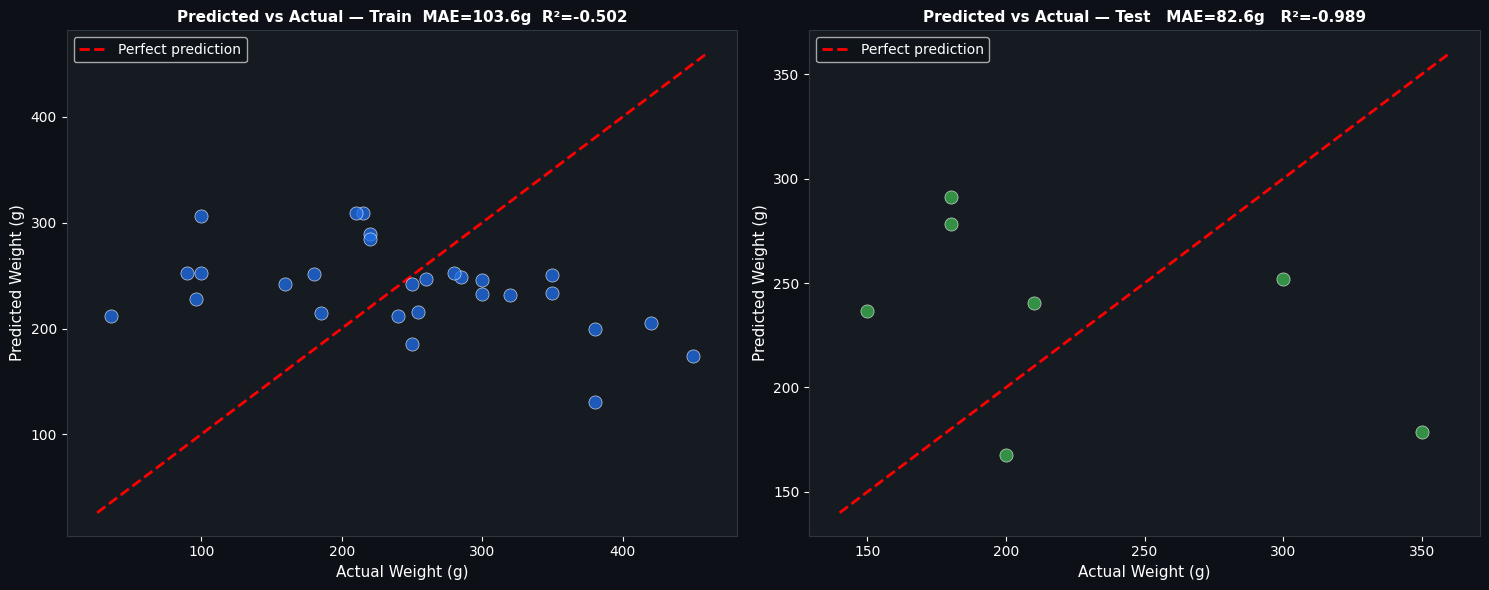

In [13]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.patch.set_facecolor('#0d1117')

for ax, (y_true, y_pred, title, color) in zip(axes, [
    (y_train, y_train_pred, f"Train  MAE={train_mae:.1f}g  R²={train_r2:.3f}", '#1f6feb'),
    (y_test,  y_test_pred,  f"Test   MAE={test_mae:.1f}g   R²={test_r2:.3f}", '#3fb950'),
]):
    ax.set_facecolor('#161b22')
    ax.scatter(y_true, y_pred, color=color, alpha=0.75,
               edgecolors='white', linewidth=0.5, s=90, zorder=3)
    mn = min(y_true.min(), y_pred.min()) - 10
    mx = max(y_true.max(), y_pred.max()) + 10
    ax.plot([mn, mx], [mn, mx], 'r--', lw=2, label='Perfect prediction')
    ax.set_xlabel('Actual Weight (g)',    color='white', fontsize=11)
    ax.set_ylabel('Predicted Weight (g)', color='white', fontsize=11)
    ax.set_title(f"Predicted vs Actual — {title}",
                 color='white', fontsize=11, fontweight='bold')
    ax.tick_params(colors='white')
    ax.spines[:].set_color('#30363d')
    ax.legend(facecolor='#0d1117', labelcolor='white')

plt.tight_layout()
plt.show()

## Test Set Bar Chart (Actual vs Predicted)

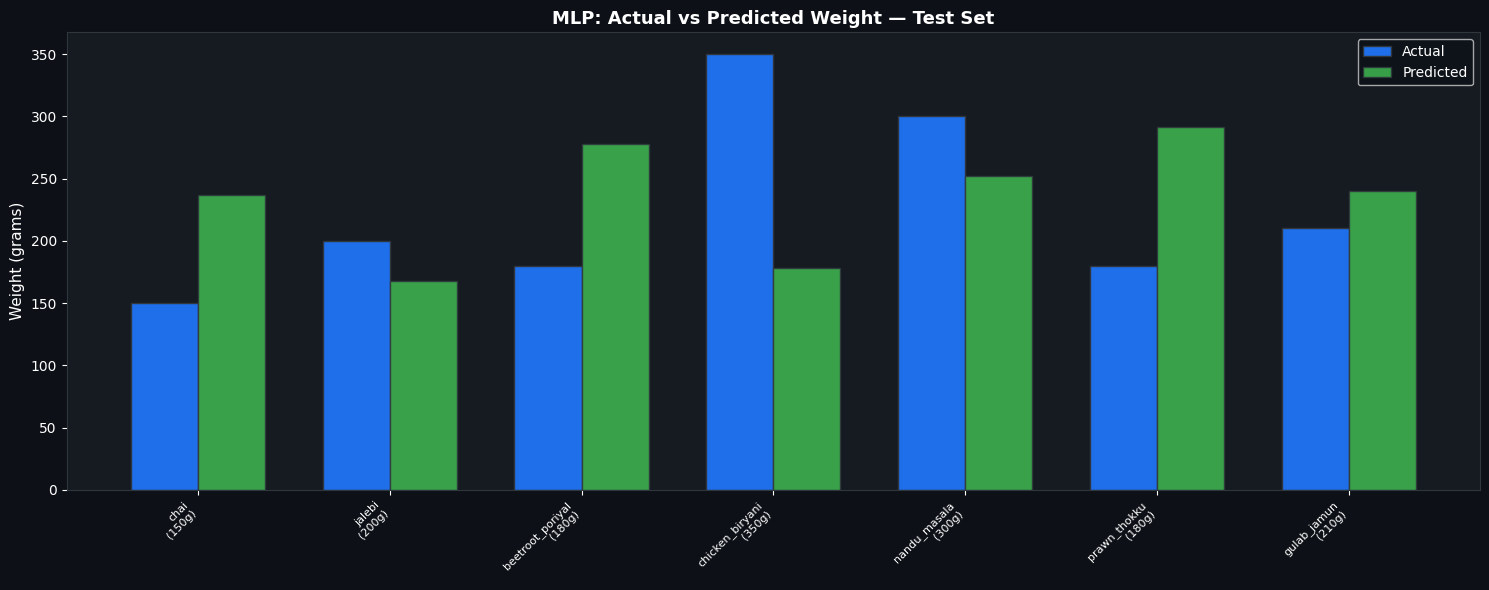


📋 Test Set Detailed Results:
      food_class  weight  predicted  error_g
            chai     150      236.7     86.7
          jalebi     200      167.9     32.1
beetroot_poriyal     180      278.1     98.1
 chicken_biryani     350      178.6    171.4
    nandu_masala     300      252.0     48.0
    prawn_thokku     180      291.4    111.4
     gulab_jamun     210      240.3     30.3


In [14]:
test_df = df_features[test_mask].copy().reset_index(drop=True)
test_df['predicted'] = y_test_pred.round(1)
test_df['error_g']   = (test_df['predicted'] - test_df['weight']).abs().round(1)

fig, ax = plt.subplots(figsize=(15, 6))
fig.patch.set_facecolor('#0d1117')
ax.set_facecolor('#161b22')

x     = np.arange(len(test_df))
width = 0.35
ax.bar(x - width/2, test_df['weight'],    width, label='Actual',
       color='#1f6feb', edgecolor='#30363d')
ax.bar(x + width/2, test_df['predicted'], width, label='Predicted',
       color='#3fb950', edgecolor='#30363d', alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(
    [f"{r['food_class']}\n({r['weight']}g)" for _, r in test_df.iterrows()],
    rotation=45, ha='right', color='white', fontsize=8
)
ax.set_ylabel('Weight (grams)', color='white', fontsize=11)
ax.set_title('MLP: Actual vs Predicted Weight — Test Set',
             color='white', fontsize=13, fontweight='bold')
ax.tick_params(colors='white')
ax.spines[:].set_color('#30363d')
ax.legend(facecolor='#0d1117', labelcolor='white', fontsize=10)

plt.tight_layout()
plt.show()

print("\n📋 Test Set Detailed Results:")
print(test_df[['food_class','weight','predicted','error_g']].to_string(index=False))

##  Loss Curve + Error Distribution

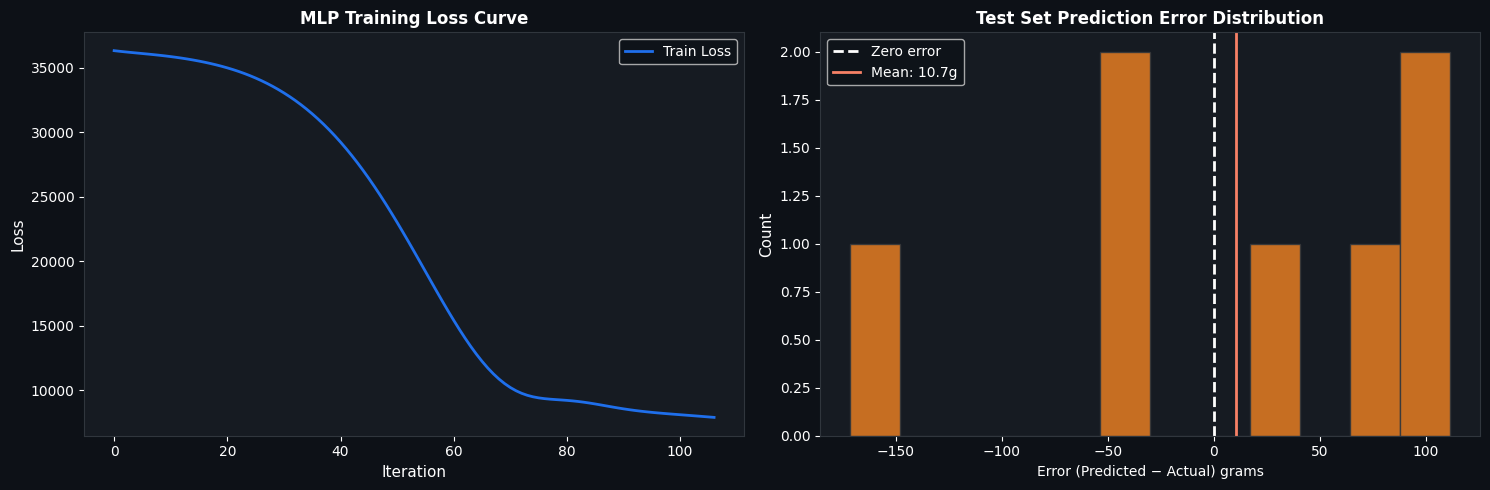

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.patch.set_facecolor('#0d1117')

# Training loss curve
ax = axes[0]
ax.set_facecolor('#161b22')
ax.plot(mlp.loss_curve_, color='#1f6feb', lw=2, label='Train Loss')
ax.set_xlabel('Iteration', color='white', fontsize=11)
ax.set_ylabel('Loss',      color='white', fontsize=11)
ax.set_title('MLP Training Loss Curve', color='white',
             fontsize=12, fontweight='bold')
ax.tick_params(colors='white')
ax.spines[:].set_color('#30363d')
ax.legend(facecolor='#0d1117', labelcolor='white')

# Error distribution
ax = axes[1]
ax.set_facecolor('#161b22')
errors = y_test_pred - y_test
ax.hist(errors, bins=12, color='#e67e22', edgecolor='#30363d', alpha=0.85)
ax.axvline(0,             color='white',   linestyle='--', lw=2, label='Zero error')
ax.axvline(errors.mean(), color='#f78166', linestyle='-',  lw=2,
           label=f'Mean: {errors.mean():.1f}g')
ax.set_xlabel('Error (Predicted − Actual) grams', color='white', fontsize=10)
ax.set_ylabel('Count',  color='white', fontsize=11)
ax.set_title('Test Set Prediction Error Distribution',
             color='white', fontsize=12, fontweight='bold')
ax.tick_params(colors='white')
ax.spines[:].set_color('#30363d')
ax.legend(facecolor='#0d1117', labelcolor='white')

plt.tight_layout()
plt.show()

## SAM-2 Mask Visualization

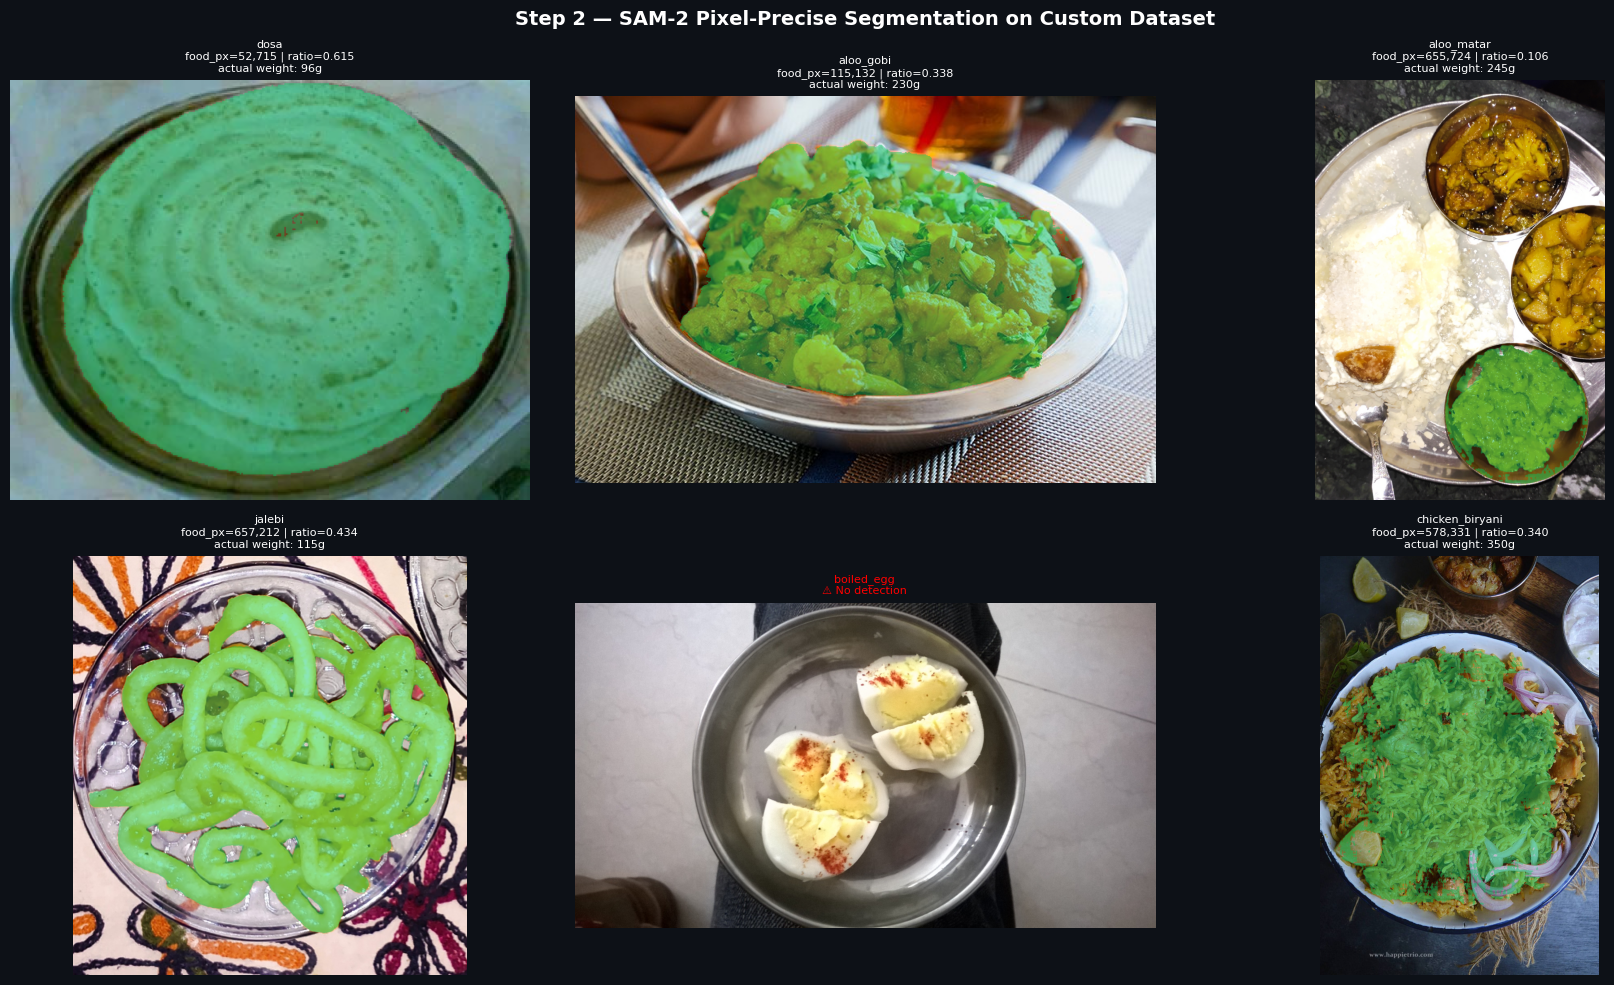

In [17]:
sample_rows = df[df['image_path'].notna()].sample(min(6, len(df)), random_state=42).reset_index(drop=True)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.patch.set_facecolor('#0d1117')
fig.suptitle("Step 2 — SAM-2 Pixel-Precise Segmentation on Custom Dataset",
             fontsize=14, fontweight='bold', color='white')

for ax, (_, row) in zip(axes.flatten(), sample_rows.iterrows()):
    result  = extract_features_with_sam2(
        row['image_path'], yolo_model, predictor, row['food_class']
    )
    img_bgr = cv2.imread(row['image_path'])
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

    if result:
        # Re-run to get mask back (we dropped it from df earlier)
        import torch
        with torch.inference_mode():
            predictor.set_image(img_rgb)
            # get bbox from yolo again
            res  = yolo_model.predict(source=row['image_path'], conf=0.15, verbose=False)[0]
            if res.boxes and len(res.boxes):
                best   = max(res.boxes, key=lambda b: float(b.conf))
                bbox   = np.array([[int(v) for v in best.xyxy[0].tolist()]])
                masks, _, _ = predictor.predict(box=bbox, multimask_output=False)
                mask   = masks[0].astype(np.uint8)

                # Green overlay
                overlay = img_rgb.copy()
                overlay[mask == 1] = [0, 200, 100]
                blended = cv2.addWeighted(img_rgb, 0.55, overlay, 0.45, 0)
                ax.imshow(blended)
                ax.set_title(
                    f"{row['food_class']}\n"
                    f"food_px={mask.sum():,} | ratio={mask.sum()/(img_rgb.shape[0]*img_rgb.shape[1]):.3f}\n"
                    f"actual weight: {row['weight']}g",
                    color='white', fontsize=8
                )
            else:
                ax.imshow(img_rgb)
                ax.set_title(f"{row['food_class']}\n⚠️ No detection", color='red', fontsize=8)
    else:
        ax.imshow(img_rgb)
        ax.set_title(f"{row['food_class']}\n⚠️ No detection", color='red', fontsize=8)

    ax.axis('off')

plt.tight_layout()
plt.show()